In [2]:
path = "../../output/protenn2/v5"

In [3]:

import json
import os.path
import pickle

import torch
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

from src.protenn2.analysis.inference import run_inference
from src.protenn2.utils import get_train_val_test_paths, get_device

# get file paths

log_path = os.path.join(path, "log")

label_encoder_path = os.path.join(path, "label_encoder.pkl")
model_path = os.path.join(path, "best_model.pt")
with open(os.path.join(path, "params.json"), "r") as f:
    params = json.load(f)
if "input_folder" not in params:
    raise ValueError("input_folder must be specified")
dataset_path = os.path.join("../../", params["input_folder"])
train_path, val_path, test_path = get_train_val_test_paths(dataset_path)

from src.protenn2.utils import calculate_max_protein_length
from src.protenn2.dataset import CathPredPerResidueDataset, create_protein_collate_fn
from src.protenn2.model import CathPredEnn2

# Initialize objects

device = get_device()
with open(label_encoder_path, "rb") as f:
    label_encoder: LabelEncoder = pickle.load(f)
num_classes = len(label_encoder.classes_)
max_protein_length = calculate_max_protein_length(dataset_path)

model = CathPredEnn2(num_classes=num_classes)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
val_dataset = CathPredPerResidueDataset(val_path, label_encoder=label_encoder,
                                        embedding_dir="../../data/embeddings/protein_embeddings_new")

collate_fn = create_protein_collate_fn(max_protein_length, val_dataset.padding_encoded_id)

val_dataloader = DataLoader(val_dataset, collate_fn=collate_fn)

y_true_labels_list, y_pred_confidences_list, protein_chain_id_list = run_inference(model=model,
                                                                                   dataloader=val_dataloader,
                                                                                   padding_encoded_id=val_dataset.padding_encoded_id,
                                                                                   device=device,
                                                                                   return_protein_chain_id=True)

Using MPS (Apple Silicon GPU).
Max protein length: 599
Dataset initialized with 1319 unique proteins.
Running inference on 1319 proteins...


Inference Progress:  22%|██▏       | 288/1319 [00:01<00:04, 222.62it/s]

Inference Progress: 100%|██████████| 1319/1319 [00:05<00:00, 232.66it/s]

Inference complete. Processed 1319 proteins


In [4]:
post_process_kwargs = {"reporting_threshold": 0.1, "region_min_length": 20, "gaussian_sigma": 1,
                       "no_domain_label_id": val_dataset.no_domain_encoded_id}


In [5]:
from src.protenn2.analysis.sample_vizualization import visualize_prediction_sample
from src.protenn2.utils import call_domains
import src.protenn2.analysis.sample_vizualization as analysis
import importlib

data = list(zip(y_true_labels_list, y_pred_confidences_list, protein_chain_id_list))


In [17]:
from matplotlib import pyplot as plt
from tqdm import tqdm

importlib.reload(analysis)
output_path = os.path.join(path, "protein_chain_vizualization")
os.makedirs(output_path, exist_ok=True)

for y_true_labels, y_pred_confidences, protein_chain_id in tqdm(data, desc="Generating visualizations"):
    fig = visualize_prediction_sample(
        y_true_labels,
        y_pred_confidences,
        label_encoder=label_encoder,
        post_process_func=call_domains,
        post_process_func_args=post_process_kwargs,
        protein_chain_id=protein_chain_id
    )
    fig.savefig(os.path.join(output_path, protein_chain_id + ".png"))
    plt.close(fig)  # Close to avoid memory accumulation


Generating visualizations: 100%|██████████| 1319/1319 [01:52<00:00, 11.70it/s]


Generating visualizations:   0%|          | 0/1319 [00:00<?, ?it/s]/var/folders/nf/_hy8vffs4dzc3cfg063rfz0w0000gn/T/ipykernel_28075/2210084206.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[<matplotlib.patches.Patch object at 0x318024980>, <matplotlib.patches.Patch object at 0x3102925d0>]
[<matplotlib.patches.Patch object at 0x3184f4b90>, <matplotlib.patches.Patch object at 0x31037d130>]


Generating visualizations:   1%|          | 8/1319 [00:00<01:06, 19.57it/s]

[<matplotlib.patches.Patch object at 0x3104ffbc0>, <matplotlib.patches.Patch object at 0x3104fcdd0>]
[]


ValueError: number sections must be larger than 0.

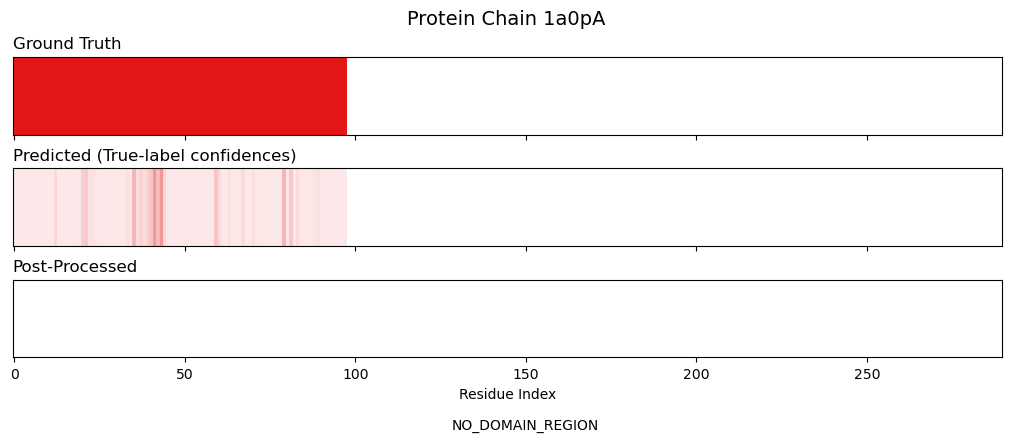

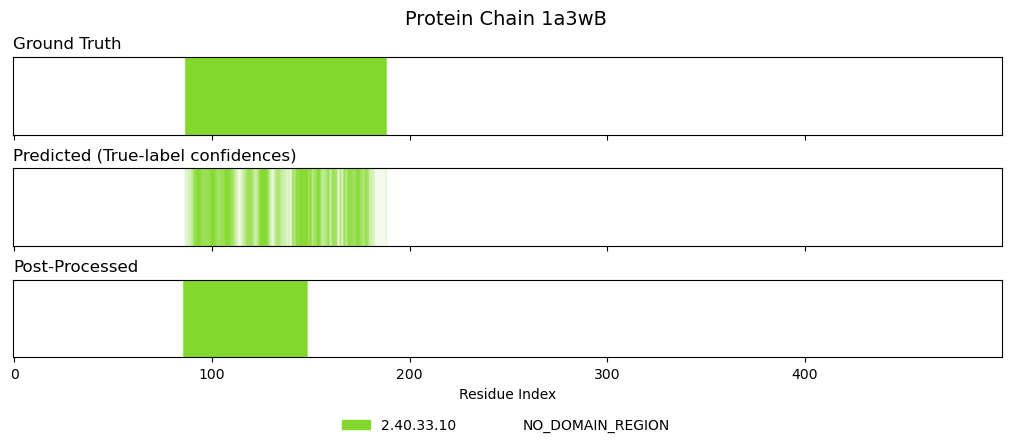

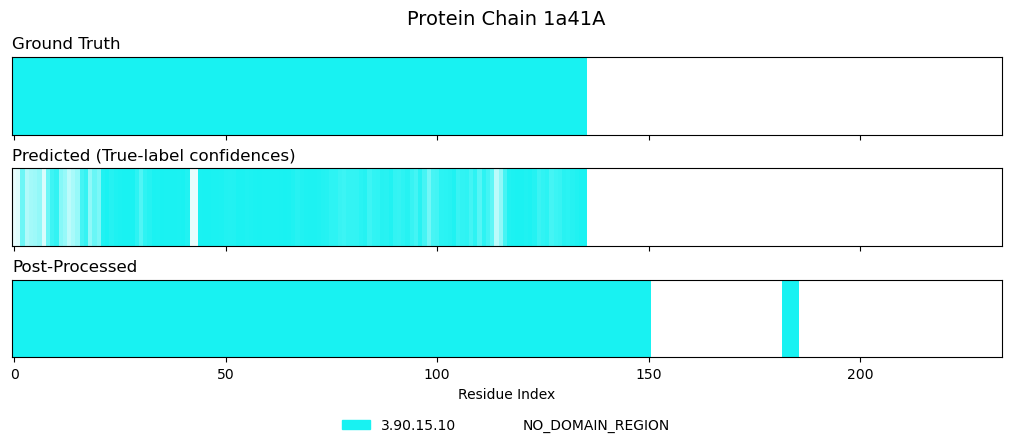

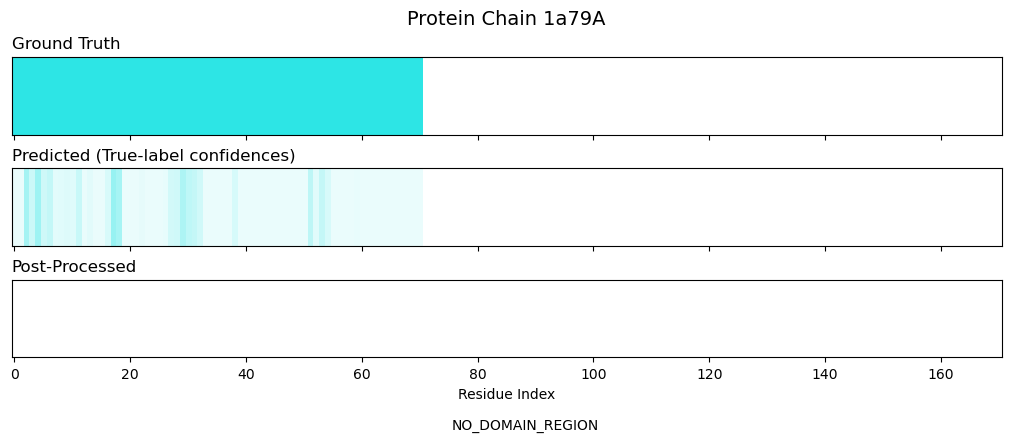

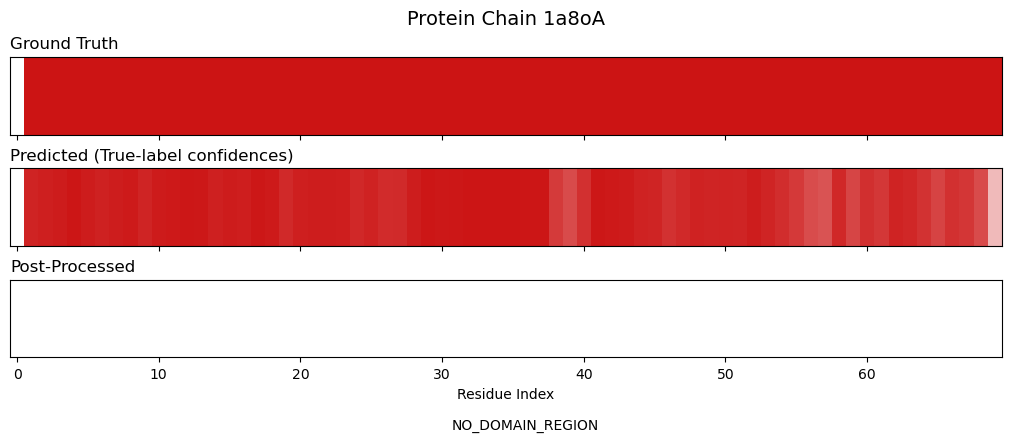

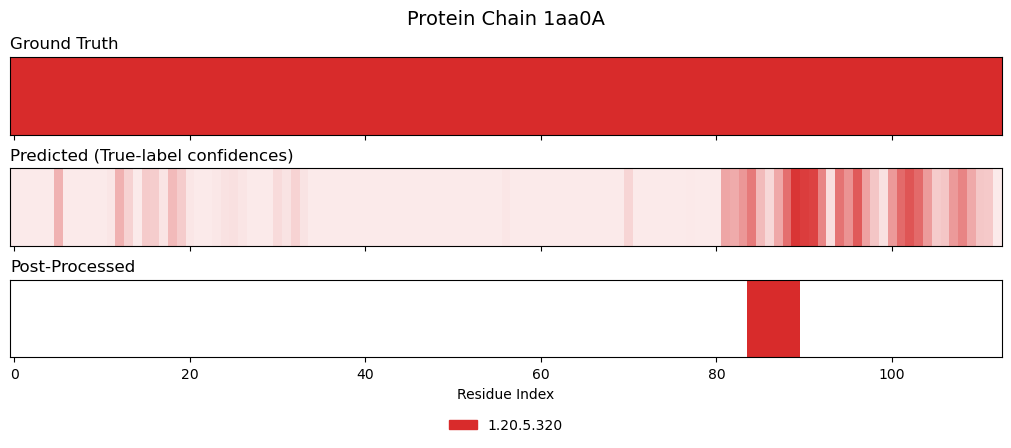

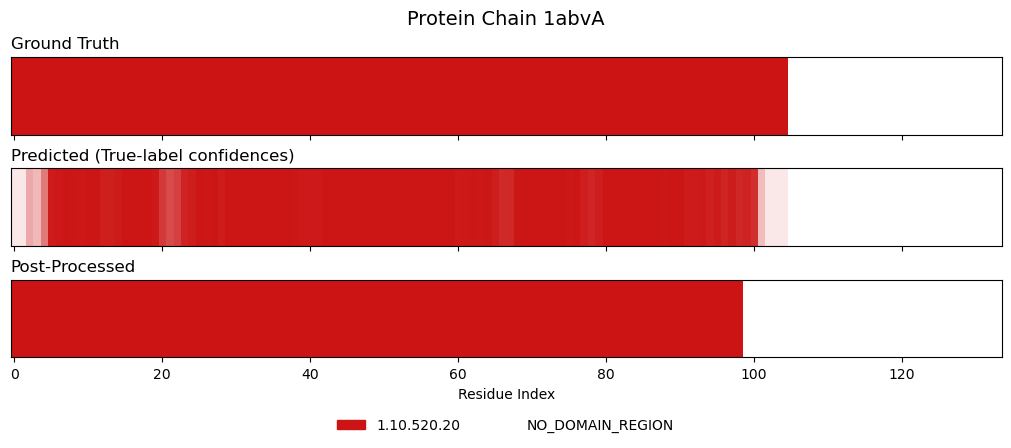

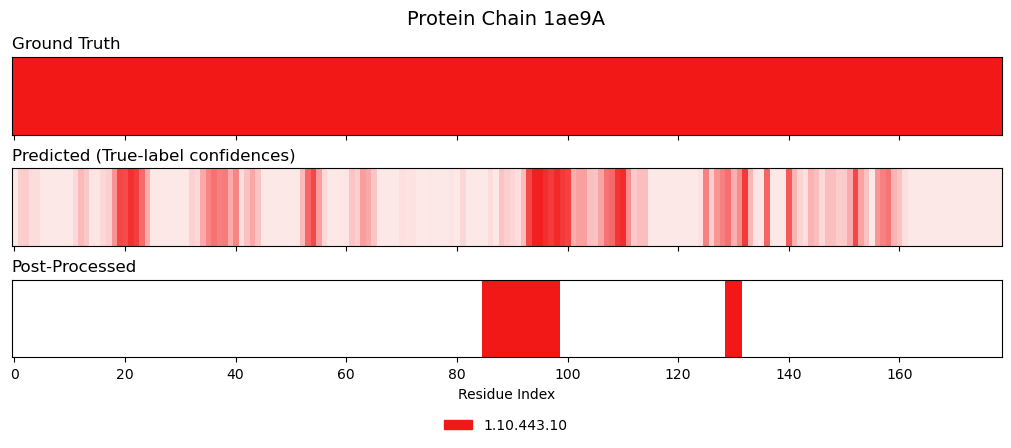

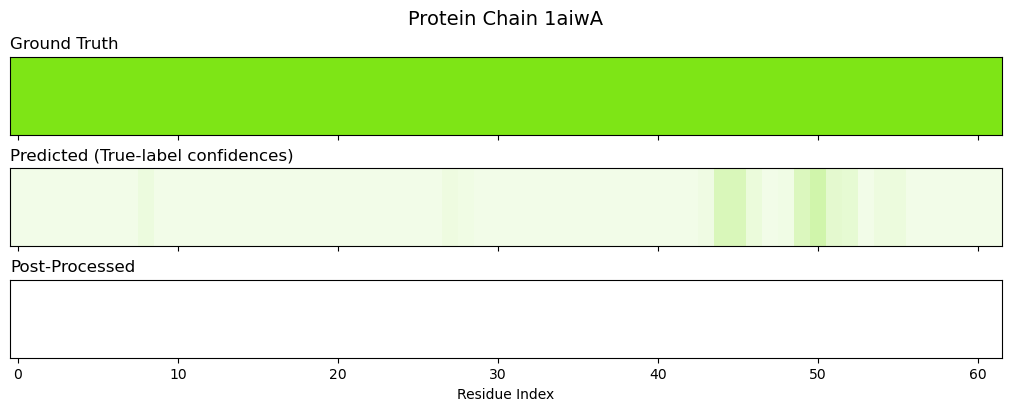

In [13]:
importlib.reload(analysis)
from tqdm import tqdm

i = 0
for y_true_labels, y_pred_confidences, protein_chain_id in tqdm(data, desc="Generating visualizations"):
    fig = analysis.visualize_prediction_sample_only_true(
        y_true_labels,
        y_pred_confidences,
        label_encoder=label_encoder,
        post_process_func=call_domains,
        post_process_func_args=post_process_kwargs,
        protein_chain_id=protein_chain_id
    )
    # fig.savefig(os.path.join(output_path, protein_chain_id + ".png"))
    fig.show()
    i += 1
    if i >= 10:
        break